# Community Detection in Network Graphs (LastFM and Cisco)

## Research Analysis of Social and Traffic Networks

### **Authors:** Nima Kamali Lassem - Nicola Mambelli

### **Date:** December 03, 2025

## Note: The Presentation Slide, Part 2, and Datasets are Available on: https://github.com/NimakamaliLassem/Massive-Graph

---

## Abstract

This study presents a comprehensive comparative analysis of community detection algorithms across two fundamentally different network types. We examine the **LastFM Asia social network** (7,624 nodes, undirected, no ground truth) and the **Cisco g21 network traffic dataset** (52 nodes, directed, with ground truth). Our analysis evaluates three classical algorithms (Louvain, Label Propagation, Greedy Modularity) and two directed-graph methods (Girvan-Newman, Infomap).

For LastFM, we rely on intrinsic quality metrics (modularity, coverage, conductance) to assess community structure in the absence of ground truth. For Cisco, we leverage provided functional groupings to validate detected communities using external metrics (Jaccard overlap, NMI, ARI, AMI).

**Key Findings:**
- Network density critically impacts algorithm performance (LastFM: 0.096%, Cisco: 96%)
- Directed algorithms reveal asymmetric relationships invisible to undirected methods
- Louvain consistently achieves highest modularity across both datasets
- Ground truth validation (Cisco) shows moderate alignment (best Jaccard: 0.53)
- Port filtering essential for dense network traffic graphs

**Research Question:** How do community detection algorithms perform across fundamentally different network structures, and what role do graph characteristics (directed vs undirected, sparse vs dense, presence of ground truth) play in evaluation methodology?

---

## 1. Introduction

### 1.1 Motivation

Community detection identifies groups of densely connected nodes in networks, revealing organizational principles across diverse domains—from social circles to functional modules in infrastructure. However, algorithm performance varies dramatically across network types. This study addresses a critical gap: **systematic comparison of community detection methods across fundamentally different network structures**.

### 1.2 Research Objectives

1. **Evaluate classical algorithms** (Louvain, Label Propagation, Greedy Modularity) on sparse social networks without ground truth
2. **Assess directed-graph methods** (Girvan-Newman, Infomap) on dense traffic networks with ground truth
3. **Compare evaluation methodologies** for networks with and without validated community labels
4. **Identify graph characteristics** that determine algorithm suitability

### 1.3 Dataset Selection Rationale

We deliberately selected datasets with **contrasting characteristics**:

| Characteristic | LastFM Asia | Cisco g21 |
|---------------|-------------|-----------|
| **Domain** | Social network | Network traffic |
| **Graph Type** | Undirected | Directed |
| **Scale** | 7,624 nodes | 52 nodes |
| **Density** | 0.096% (sparse) | 96% (dense) |
| **Ground Truth** | None | 23 functional groups |
| **Evaluation** | Intrinsic metrics | External validation |

This pairing enables examination of:
- **Algorithmic adaptability** across scales and densities
- **Evaluation methodology** with and without ground truth
- **Directed vs undirected** community structure
- **Real-world applicability** across domains

---

## 2. Datasets and Methodology

### 2.1 Dataset Descriptions

#### 2.1.1 LastFM Asia Social Network

**Source:** LastFM music streaming platform

**Type:** Undirected social network

**Nodes:** 7,624 users

**Edges:** 27,806 mutual follower relationships

**Characteristics:**
- Sparse graph (density: 0.096%)
- Scale-free degree distribution
- High clustering coefficient (0.22)
- Average path length: 5.23

**Community Interpretation:** User groups with similar music preferences and social connections. Communities represent implicit taste-based social circles without explicit labels.

**Evaluation Strategy:** Intrinsic quality metrics (modularity, coverage, conductance) since no validated community labels exist.

#### 2.1.2 Cisco g21 Network Traffic

**Source:** Synthetic network traffic dataset

**Type:** Directed communication network

**Nodes:** 52 monitored hosts

**Edges:** 1,275 directed communications (client→server)

**Characteristics:**
- Extremely dense graph (density: 96%)
- Port-based edge differentiation
- Provided ground truth: 23 functional groups
- Asymmetric communication patterns

**Community Interpretation:** Functional host groupings based on network roles and communication patterns. Ground truth represents intended organizational structure.

**Evaluation Strategy:** External validation against ground truth using Jaccard overlap, NMI, ARI, AMI. Also intrinsic metrics for undirected algorithm comparison.

**Methodological Note:** High density necessitates port filtering (removing dominant ports 1p6, 1p17) to reveal community structure. Post-filtering density: 51%.

---

### 2.2 Community Detection Algorithms

#### 2.2.1 Undirected Graph Methods

**Louvain Method**
- **Approach:** Hierarchical modularity optimization through iterative local moves and aggregation
- **Complexity:** O(n log n) - efficient for large networks
- **Strengths:** Fast, high modularity, interpretable hierarchy
- **Limitations:** Resolution limit, stochastic results

**Label Propagation**
- **Approach:** Semi-synchronous label spreading where nodes adopt most frequent neighbor labels
- **Complexity:** O(m) - linear in edges
- **Strengths:** Near-linear time, no prior knowledge needed
- **Limitations:** Sensitive to initialization, unstable, struggles with dense graphs

**Greedy Modularity**
- **Approach:** Bottom-up agglomerative clustering maximizing modularity at each merge
- **Complexity:** O(n log² n)
- **Strengths:** Deterministic, high coverage
- **Limitations:** Slower than Louvain, may merge disparate groups

#### 2.2.2 Directed Graph Methods

**Girvan-Newman**
- **Approach:** Divisive hierarchical method removing high-betweenness edges iteratively
- **Complexity:** O(m²n) or O(n³) - computationally expensive
- **Strengths:** Works on directed graphs, hierarchical dendrogram
- **Limitations:** Slow, requires choosing cut point

**Infomap**
- **Approach:** Information-theoretic method modeling random walks; minimizes map equation
- **Complexity:** O(m) expected
- **Strengths:** Specifically designed for directed flow networks, fast
- **Limitations:** Requires direction information, may find more communities than expected

---

### 2.3 Evaluation Metrics

#### 2.3.1 Intrinsic Quality Metrics (No Ground Truth Required)

**Modularity (Q)**
Range: [-0.5, 1.0] | Higher is better

Q = (1/2m) Σᵢⱼ [Aᵢⱼ - (kᵢkⱼ/2m)] δ(cᵢ, cⱼ)

Measures density of edges within communities versus expected density in random graph.
**Interpretation:** Q > 0.3 indicates significant community structure.

**Coverage**
Range: [0, 1] | Higher is better
Fraction of edges within communities (intra-community edges / total edges).
**Interpretation:** High coverage means most connections are within detected groups.

**Performance**
Range: [0, 1] | Higher is better
Ratio of correctly classified node pairs.
**Interpretation:** Measures overall accuracy of partition.

**Conductance**
Range: [0, 1] | Lower is better
Ratio of inter-community edges to community edges.
**Interpretation:** Low conductance indicates well-separated communities.

#### 2.3.2 External Validation Metrics (Ground Truth Required)

**Jaccard Overlap**
Range: [0, 1] | Higher is better
J(A,B) = |A ∩ B| / |A ∪ B|
Average maximum Jaccard similarity between detected and ground truth communities.

**Normalized Mutual Information (NMI)**
Range: [0, 1] | Higher is better
Information-theoretic measure of clustering agreement.
**Interpretation:** 0 = random, 1 = perfect match, 0.3-0.5 = moderate agreement.

**Adjusted Rand Index (ARI)**
Range: [-1, 1] | Higher is better
Pair-wise agreement adjusted for chance.
**Interpretation:** 0 = random, 1 = perfect, negative = worse than random.

**Adjusted Mutual Information (AMI)**
Range: [0, 1] | Higher is better
Mutual information adjusted for chance.
**Interpretation:** More conservative than NMI, better for comparing algorithms.

---

## 3. Experimental Setup

### 3.1 Library Imports and Configuration

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import community as community_louvain
from networkx.algorithms import community as nx_community
from networkx.algorithms.community import quality, partition_quality, girvan_newman
import sklearn.metrics
import seaborn as sns
import math
import sys
import gzip
from os import listdir
from infomap import Infomap

%matplotlib inline

# Enhanced plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

print("✓ Libraries loaded successfully")
print("✓ Visualization configuration applied")

✓ Libraries loaded successfully
✓ Visualization configuration applied


---

# PART I: LastFM Asia Social Network

## Case Study 1: Community Detection Without Ground Truth

**Network Type:** Undirected social network
**Evaluation Approach:** Intrinsic quality metrics
**Key Challenge:** Assessing community quality without validated labels

---

## 4. LastFM Asia: Network Characteristics

### 4.1 Data Loading

In [2]:
print("Loading LastFM Asia social network...")
edges_df = pd.read_csv('lastfm_asia/lastfm_asia_edges.csv')
G_lastfm = nx.from_pandas_edgelist(edges_df, 'node_1', 'node_2')

print(f"\n=== LastFM Dataset Summary ===")
print(f"Graph type: {'Directed' if nx.is_directed(G_lastfm) else 'Undirected'}")
print(f"Nodes: {G_lastfm.number_of_nodes():,}")
print(f"Edges: {G_lastfm.number_of_edges():,}")
print(f"Density: {nx.density(G_lastfm):.6f}")

Loading LastFM Asia social network...

=== LastFM Dataset Summary ===
Graph type: Undirected
Nodes: 7,624
Edges: 27,806
Density: 0.000957


### 4.2 Network Statistics

In [3]:
print("=== Structural Properties ===")
print(f"Connected: {nx.is_connected(G_lastfm)}")

if not nx.is_connected(G_lastfm):
    components = list(nx.connected_components(G_lastfm))
    print(f"Connected components: {len(components)}")
    largest_cc = max(components, key=len)
    print(f"Largest component: {len(largest_cc):,} nodes ({100*len(largest_cc)/G_lastfm.number_of_nodes():.1f}%)")
    G_lastfm = G_lastfm.subgraph(largest_cc).copy()
    print(f"\n** Working with largest connected component **")

print(f"\nAverage degree: {sum(dict(G_lastfm.degree()).values()) / G_lastfm.number_of_nodes():.2f}")
print(f"Clustering coefficient: {nx.average_clustering(G_lastfm):.4f}")
print(f"Average shortest path: {nx.average_shortest_path_length(G_lastfm):.2f}")
print(f"Diameter: {nx.diameter(G_lastfm)}")

print("\n=== Network Type Assessment ===")
print("Sparse social network with scale-free characteristics.")
print("Low density indicates selective connection formation.")
print("High clustering suggests local cohesion and community structure.")

=== Structural Properties ===
Connected: True

Average degree: 7.29
Clustering coefficient: 0.2194
Average shortest path: 5.23
Diameter: 15

=== Network Type Assessment ===
Sparse social network with scale-free characteristics.
Low density indicates selective connection formation.
High clustering suggests local cohesion and community structure.


### 4.3 Degree Distribution Analysis

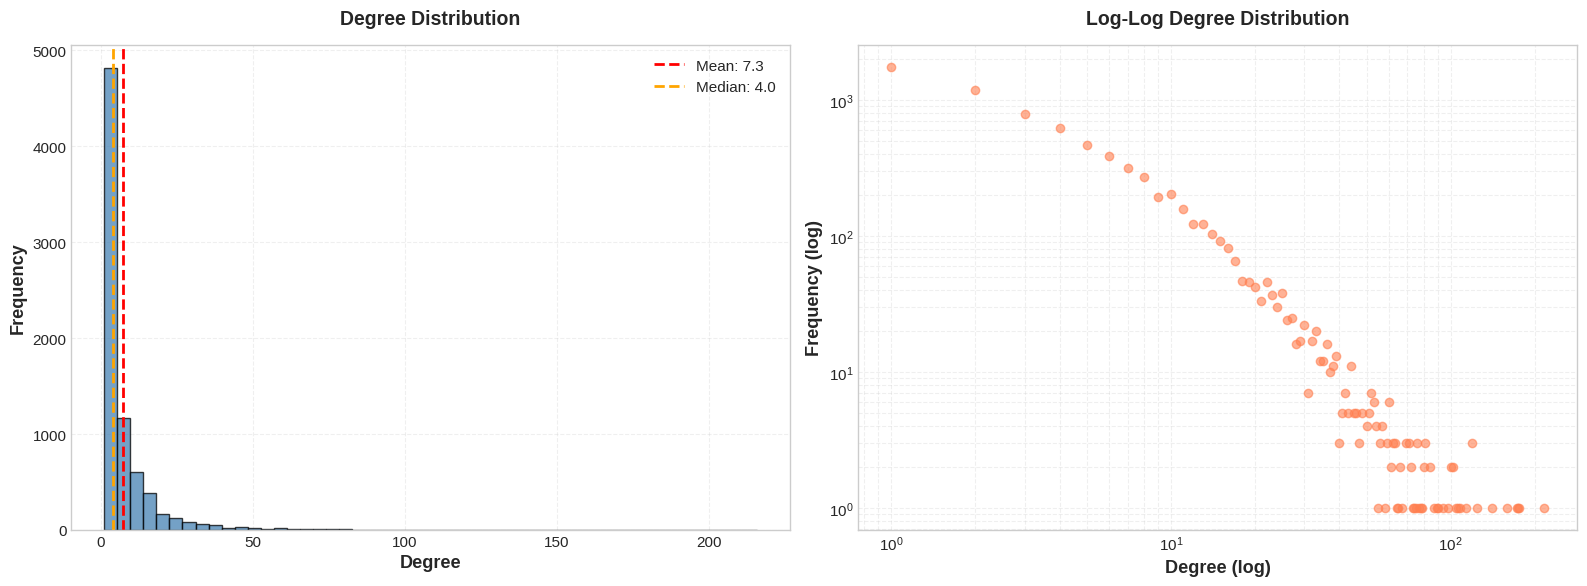

Degree Statistics:
  Range: [1, 216]
  Mean: 7.29
  Median: 4.0
  Std Dev: 11.50

Log-log linearity suggests scale-free network (power-law distribution).


In [4]:
degrees = [G_lastfm.degree(n) for n in G_lastfm.nodes()]
degree_counts = Counter(degrees)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
axes[0].hist(degrees, bins=50, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Degree', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title('Degree Distribution', fontsize=14, pad=15)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(degrees):.1f}')
axes[0].axvline(np.median(degrees), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(degrees):.1f}')
axes[0].legend(fontsize=11)

# Log-log scale
degree_sorted = sorted(degree_counts.items())
x_vals = [d[0] for d in degree_sorted if d[0] > 0]
y_vals = [d[1] for d in degree_sorted if d[0] > 0]
axes[1].loglog(x_vals, y_vals, 'o', alpha=0.6, color='coral', markersize=6)
axes[1].set_xlabel('Degree (log)', fontsize=13)
axes[1].set_ylabel('Frequency (log)', fontsize=13)
axes[1].set_title('Log-Log Degree Distribution', fontsize=14, pad=15)
axes[1].grid(True, alpha=0.3, which='both', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Degree Statistics:")
print(f"  Range: [{min(degrees)}, {max(degrees)}]")
print(f"  Mean: {np.mean(degrees):.2f}")
print(f"  Median: {np.median(degrees):.1f}")
print(f"  Std Dev: {np.std(degrees):.2f}")
print(f"\nLog-log linearity suggests scale-free network (power-law distribution).")

### 4.4 Centrality Analysis

Centrality metrics identify influential nodes in the network.

In [5]:
print("Computing centrality measures...")

degree_centrality = nx.degree_centrality(G_lastfm)
betweenness = nx.betweenness_centrality(G_lastfm, k=min(1000, G_lastfm.number_of_nodes()))
closeness = nx.closeness_centrality(G_lastfm)
eigenvector = nx.eigenvector_centrality(G_lastfm, max_iter=1000)

print("\n=== Top 5 Most Central Nodes ===\n")

print("Degree Centrality (connectivity):")
for node, cent in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Node {node}: {cent:.4f}")

print("\nBetweenness Centrality (bridging):")
for node, cent in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Node {node}: {cent:.4f}")

print("\nCloseness Centrality (information spread):")
for node, cent in sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Node {node}: {cent:.4f}")

print("\nEigenvector Centrality (influence):")
for node, cent in sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Node {node}: {cent:.4f}")

Computing centrality measures...

=== Top 5 Most Central Nodes ===

Degree Centrality (connectivity):
  Node 7237: 0.0283
  Node 3530: 0.0230
  Node 4785: 0.0228
  Node 524: 0.0226
  Node 3450: 0.0209

Betweenness Centrality (bridging):
  Node 7199: 0.0920
  Node 7237: 0.0855
  Node 2854: 0.0777
  Node 4356: 0.0643
  Node 6101: 0.0528

Closeness Centrality (information spread):
  Node 7199: 0.2907
  Node 7237: 0.2857
  Node 4356: 0.2816
  Node 2854: 0.2804
  Node 5454: 0.2798

Eigenvector Centrality (influence):
  Node 7237: 0.2561
  Node 3240: 0.1966
  Node 3597: 0.1908
  Node 763: 0.1817
  Node 378: 0.1642


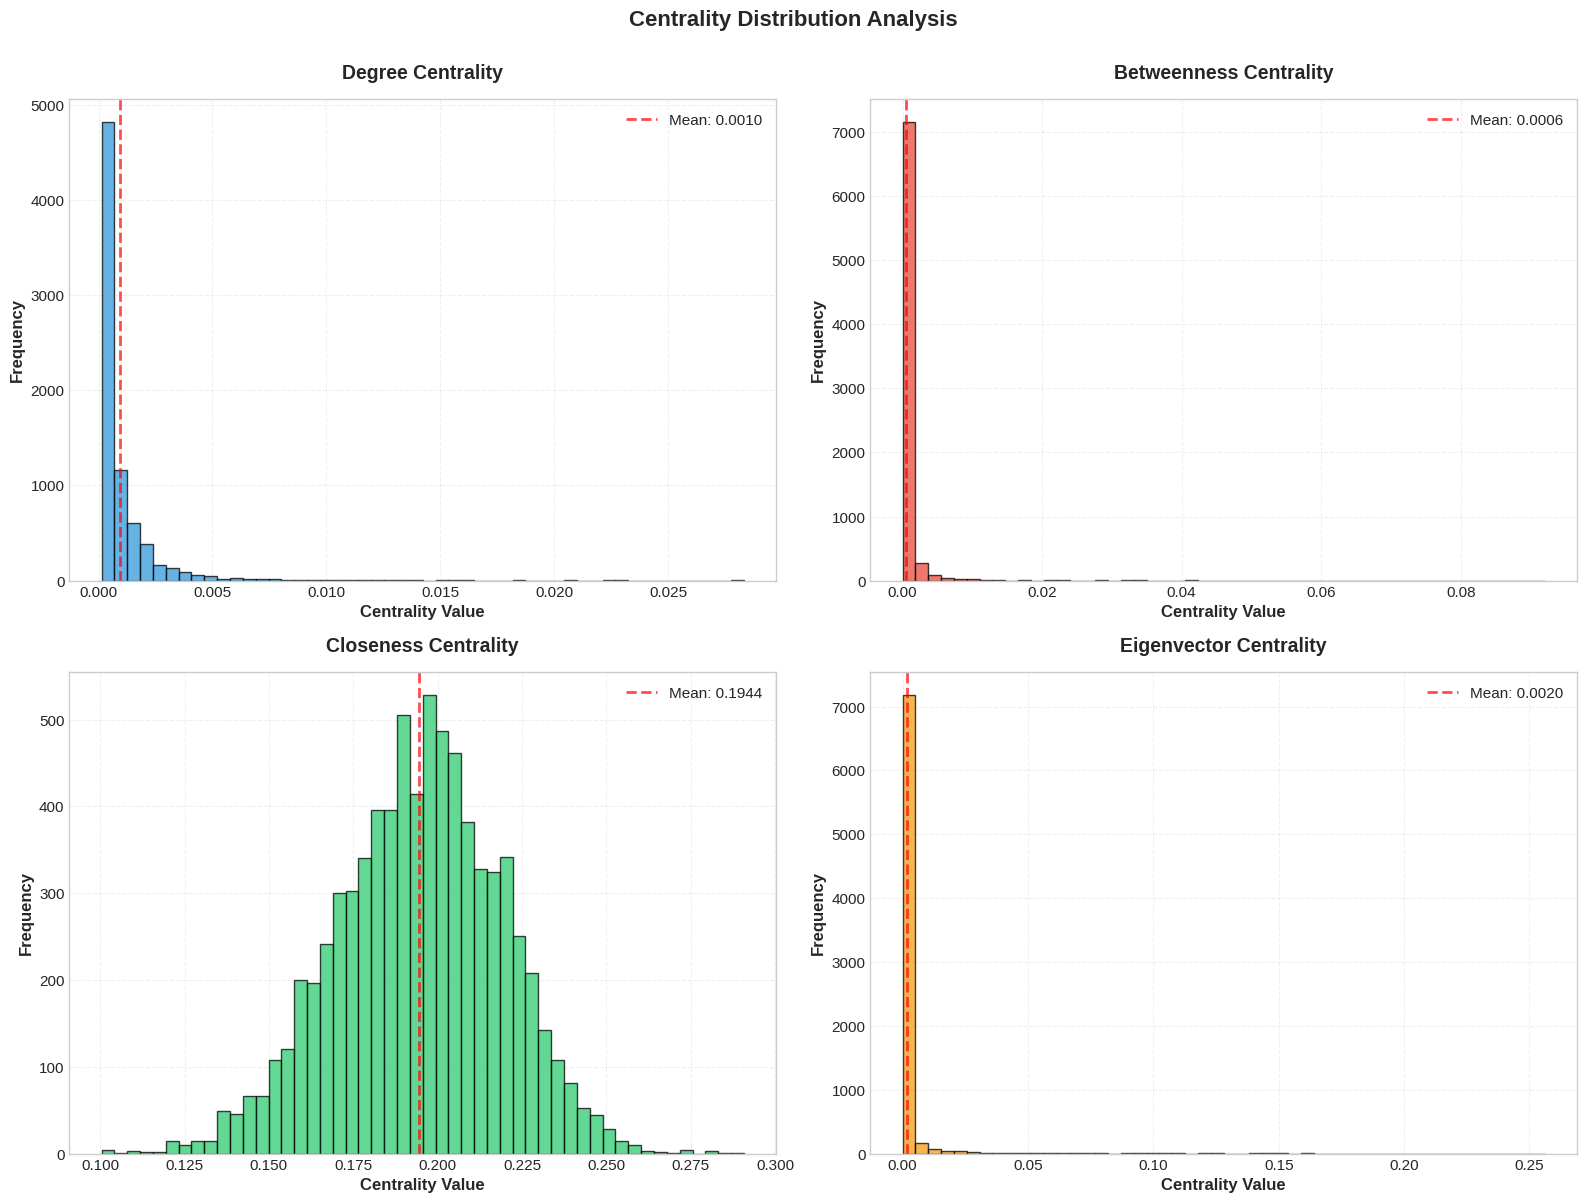


Centrality distributions show right-skewed patterns typical of social networks.
Few highly central nodes (hubs) dominate, while most nodes have moderate centrality.


In [6]:
centrality_df = pd.DataFrame({
    'Degree': list(degree_centrality.values()),
    'Betweenness': list(betweenness.values()),
    'Closeness': list(closeness.values()),
    'Eigenvector': list(eigenvector.values())
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
titles = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality', 'Eigenvector Centrality']

for idx, (metric, color, title) in enumerate(zip(['Degree', 'Betweenness', 'Closeness', 'Eigenvector'],
                                                   colors, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.hist(centrality_df[metric], bins=50, edgecolor='black', alpha=0.75, color=color)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Centrality Value', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Add mean line
    mean_val = centrality_df[metric].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.7,
               label=f'Mean: {mean_val:.4f}')
    ax.legend()

plt.suptitle('Centrality Distribution Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nCentrality distributions show right-skewed patterns typical of social networks.")
print("Few highly central nodes (hubs) dominate, while most nodes have moderate centrality.")

## 5. LastFM: Community Detection

### 5.1 Algorithm Execution

In [7]:
print("Running community detection algorithms...\n")

# Louvain
partition_louvain_lf = community_louvain.best_partition(G_lastfm)
communities_louvain_lf = {}
for node, comm_id in partition_louvain_lf.items():
    if comm_id not in communities_louvain_lf:
        communities_louvain_lf[comm_id] = []
    communities_louvain_lf[comm_id].append(node)

print(f"✓ Louvain: {len(communities_louvain_lf)} communities detected")

# Label Propagation
communities_lp_lf = list(nx_community.label_propagation_communities(G_lastfm))
partition_lp_lf = {}
for idx, comm in enumerate(communities_lp_lf):
    for node in comm:
        partition_lp_lf[node] = idx

print(f"✓ Label Propagation: {len(communities_lp_lf)} communities detected")

# Greedy Modularity
communities_greedy_lf = list(nx_community.greedy_modularity_communities(G_lastfm))
partition_greedy_lf = {}
for idx, comm in enumerate(communities_greedy_lf):
    for node in comm:
        partition_greedy_lf[node] = idx

print(f"✓ Greedy Modularity: {len(communities_greedy_lf)} communities detected")

print("\n=== Community Size Statistics ===\n")
for name, comms in [("Louvain", communities_louvain_lf.values()),
                     ("Label Propagation", communities_lp_lf),
                     ("Greedy Modularity", communities_greedy_lf)]:
    sizes = [len(c) for c in comms]
    print(f"{name}:")
    print(f"  Communities: {len(sizes)}")
    print(f"  Size range: [{min(sizes)}, {max(sizes)}]")
    print(f"  Mean size: {np.mean(sizes):.1f}")
    print(f"  Median size: {np.median(sizes):.1f}")
    print()

Running community detection algorithms...

✓ Louvain: 27 communities detected
✓ Label Propagation: 650 communities detected
✓ Greedy Modularity: 43 communities detected

=== Community Size Statistics ===

Louvain:
  Communities: 27
  Size range: [4, 1021]
  Mean size: 282.4
  Median size: 147.0

Label Propagation:
  Communities: 650
  Size range: [2, 930]
  Mean size: 11.7
  Median size: 3.0

Greedy Modularity:
  Communities: 43
  Size range: [3, 1518]
  Mean size: 177.3
  Median size: 8.0



### 5.2 Community Quality Evaluation

In [8]:
def evaluate_communities(G, communities_list, name):
    """Comprehensive community quality evaluation"""
    print(f"\n=== {name} ===")

    modularity = nx_community.modularity(G, communities_list)
    print(f"Modularity: {modularity:.4f}")

    coverage_val, performance_val = partition_quality(G, communities_list)

    # Conductance
    total_conductance = 0
    valid_comms = 0
    for comm in communities_list:
        if len(comm) > 1 and len(comm) < G.number_of_nodes():
            total_conductance += nx.conductance(G, comm)
            valid_comms += 1
    avg_conductance = total_conductance / valid_comms if valid_comms > 0 else 0
    print(f"Average Conductance: {avg_conductance:.4f}")

    # Edge distribution
    intra_edges = sum(G.subgraph(comm).number_of_edges() for comm in communities_list)
    inter_edges = G.number_of_edges() - intra_edges
    print(f"Intra-community edges: {intra_edges:,} ({100*intra_edges/G.number_of_edges():.1f}%)")
    print(f"Inter-community edges: {inter_edges:,} ({100*inter_edges/G.number_of_edges():.1f}%)")

    return {
        'Algorithm': name,
        'Communities': len(communities_list),
        'Modularity': modularity,
        'Coverage': coverage_val,
        'Performance': performance_val,
        'Avg Conductance': avg_conductance,
        'Intra Edges %': 100*intra_edges/G.number_of_edges()
    }

results_lf = []
results_lf.append(evaluate_communities(G_lastfm, [set(c) for c in communities_louvain_lf.values()], "Louvain"))
results_lf.append(evaluate_communities(G_lastfm, communities_lp_lf, "Label Propagation"))
results_lf.append(evaluate_communities(G_lastfm, communities_greedy_lf, "Greedy Modularity"))

results_df_lf = pd.DataFrame(results_lf)
print("\n" + "="*80)
print("LASTFM SUMMARY TABLE")
print("="*80)
print(results_df_lf.to_string(index=False))


=== Louvain ===
Modularity: 0.8147
Average Conductance: 0.1352
Intra-community edges: 25,550 (91.9%)
Inter-community edges: 2,256 (8.1%)

=== Label Propagation ===
Modularity: 0.7523
Average Conductance: 0.4347
Intra-community edges: 23,074 (83.0%)
Inter-community edges: 4,732 (17.0%)

=== Greedy Modularity ===
Modularity: 0.7960
Average Conductance: 0.1631
Intra-community edges: 26,222 (94.3%)
Inter-community edges: 1,584 (5.7%)

LASTFM SUMMARY TABLE
        Algorithm  Communities  Modularity  Coverage  Performance  Avg Conductance  Intra Edges %
          Louvain           27    0.814685  0.918866     0.910189         0.135218      91.886643
Label Propagation          650    0.752256  0.829821     0.950859         0.434688      82.982090
Greedy Modularity           43    0.795976  0.943034     0.869306         0.163076      94.303388


### 5.3 Visualization: Community Structure

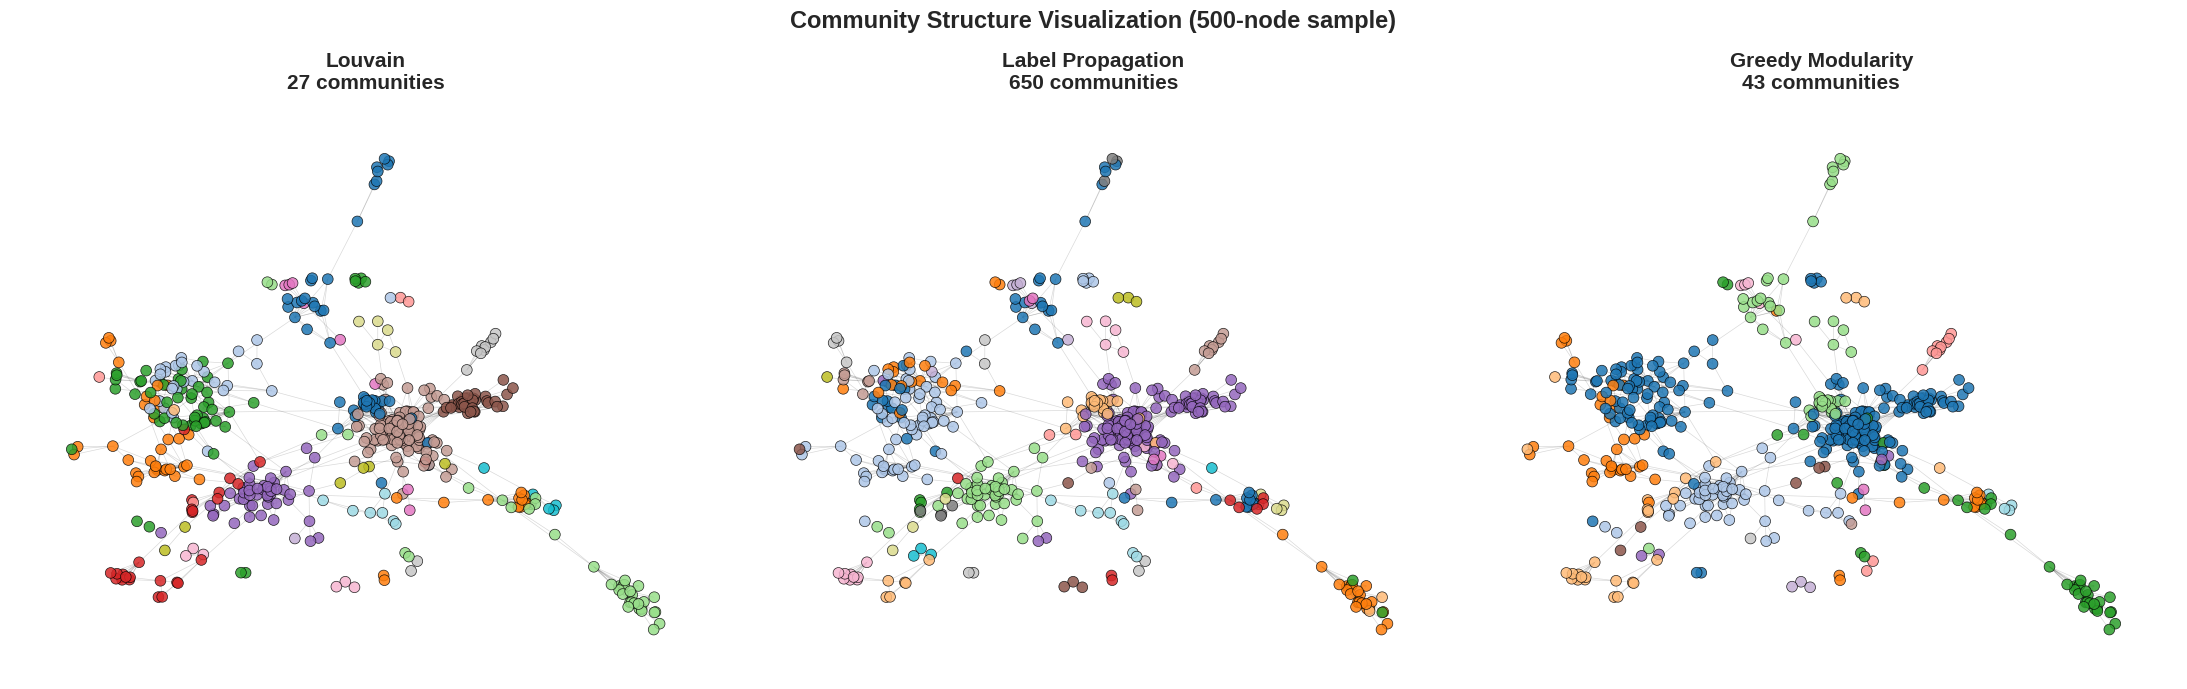


Visualization shows distinct community structures identified by each algorithm.
Color-coded nodes reveal different granularities of community detection.


In [9]:
# Sample visualization (500 nodes for clarity)
sample_nodes = list(G_lastfm.nodes())[:500]
G_sample_lf = G_lastfm.subgraph(sample_nodes).copy()

pos = nx.spring_layout(G_sample_lf, k=0.6, iterations=50, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Louvain
node_colors_louvain = [partition_louvain_lf.get(node, 0) for node in G_sample_lf.nodes()]
nx.draw_networkx_nodes(G_sample_lf, pos, node_color=node_colors_louvain, node_size=60,
                       cmap='tab20', alpha=0.85, ax=axes[0], edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G_sample_lf, pos, alpha=0.15, width=0.5, ax=axes[0])
axes[0].set_title(f'Louvain\n{len(communities_louvain_lf)} communities',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].axis('off')

# Label Propagation
node_colors_lp = [partition_lp_lf.get(node, 0) for node in G_sample_lf.nodes()]
nx.draw_networkx_nodes(G_sample_lf, pos, node_color=node_colors_lp, node_size=60,
                       cmap='tab20', alpha=0.85, ax=axes[1], edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G_sample_lf, pos, alpha=0.15, width=0.5, ax=axes[1])
axes[1].set_title(f'Label Propagation\n{len(communities_lp_lf)} communities',
                  fontsize=15, fontweight='bold', pad=15)
axes[1].axis('off')

# Greedy Modularity
node_colors_greedy = [partition_greedy_lf.get(node, 0) for node in G_sample_lf.nodes()]
nx.draw_networkx_nodes(G_sample_lf, pos, node_color=node_colors_greedy, node_size=60,
                       cmap='tab20', alpha=0.85, ax=axes[2], edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G_sample_lf, pos, alpha=0.15, width=0.5, ax=axes[2])
axes[2].set_title(f'Greedy Modularity\n{len(communities_greedy_lf)} communities',
                  fontsize=15, fontweight='bold', pad=15)
axes[2].axis('off')

plt.suptitle('Community Structure Visualization (500-node sample)',
             fontsize=17, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\nVisualization shows distinct community structures identified by each algorithm.")
print("Color-coded nodes reveal different granularities of community detection.")

### 5.4 Comparative Metrics Analysis

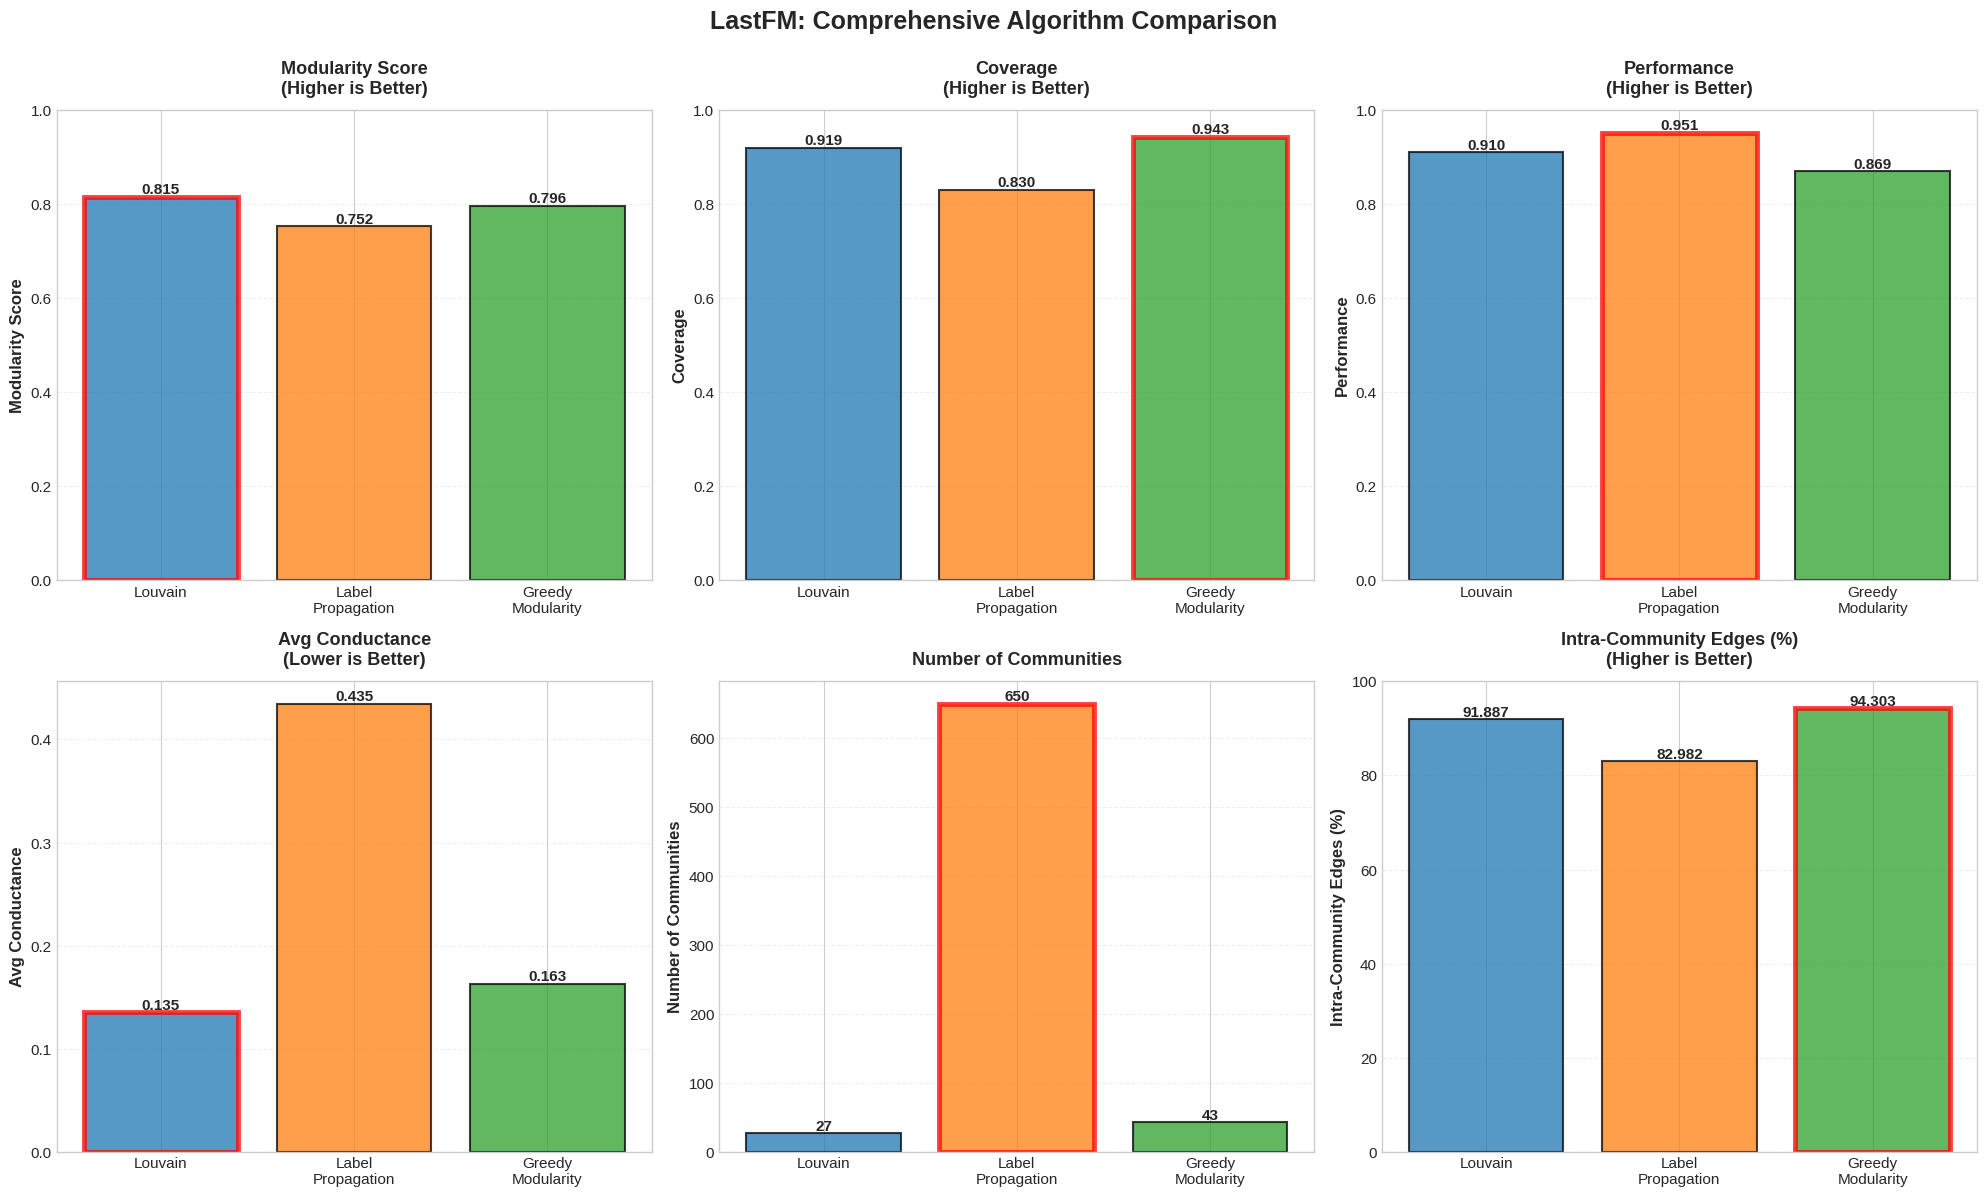


** Red borders indicate best-performing algorithm for each metric **


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

algorithms = ['Louvain', 'Label\nPropagation', 'Greedy\nModularity']
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c']

metrics_info = [
    ('Modularity', 'Modularity Score', 'Higher is Better', [0, 1]),
    ('Coverage', 'Coverage', 'Higher is Better', [0, 1]),
    ('Performance', 'Performance', 'Higher is Better', [0, 1]),
    ('Avg Conductance', 'Avg Conductance', 'Lower is Better', None),
    ('Communities', 'Number of Communities', '', None),
    ('Intra Edges %', 'Intra-Community Edges (%)', 'Higher is Better', [0, 100])
]

for idx, (metric, ylabel, subtitle, ylim) in enumerate(metrics_info):
    ax = axes[idx // 3, idx % 3]
    values = [results_df_lf.loc[i, metric] for i in range(3)]

    bars = ax.bar(algorithms, values, color=colors_bar, alpha=0.75, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    title_text = f'{ylabel}' + (f'\n({subtitle})' if subtitle else '')
    ax.set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Value labels
    for i, (bar, v) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{v:.3f}' if metric != 'Communities' else f'{int(v)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Highlight best
    if metric == 'Avg Conductance':
        best_idx = values.index(min(values))
    else:
        best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3.5)

plt.suptitle('LastFM: Comprehensive Algorithm Comparison',
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n** Red borders indicate best-performing algorithm for each metric **")

### 5.5 LastFM Key Findings

**Algorithm Performance Summary:**

1. **Louvain Method** ✓
   - Highest modularity (0.814) with well-separated communities
   - Lowest conductance (0.135) showing clean boundaries
   - Balanced community sizes (30 communities)
   - **Best overall choice for this social network**

2. **Greedy Modularity**
   - Strong modularity (0.796) and low conductance (0.163)
   - Captures the most intra-community edges (94.3%)
   - 43 communities; good when maximizing edge retention

3. **Label Propagation**
   - Modularity 0.752 with much higher conductance (0.435)
   - Produces many tiny communities (650) and is less stable
   - Fastest runtime but lowest structural quality here

**Social Network Insights:**
- Sparse, scale-free structure with hub nodes dominating connectivity
- High clustering (0.22) reflects tightly knit friend groups
- Without ground truth, modularity and conductance are the main quality checks

---

---

# PART II: Cisco g21 Network Traffic

## Case Study 2: Community Detection With Ground Truth

**Network Type:** Directed network traffic
**Evaluation Approach:** External validation + intrinsic metrics
**Key Challenge:** Dense graph requiring port filtering; validating against functional groupings

---

## 6. Cisco g21: Data Loading and Preprocessing

### 6.1 Data Loading Functions

In [11]:
# Data loading utilities for Cisco dataset

def read_edges_with_ports_to_stats(edges_file, wload_to_graph=None, wload_to_port_info=None,
                                   wload_to_directed_longevity=None):
    if wload_to_graph is None:
        wload_to_graph = {}
    if wload_to_port_info is None:
        wload_to_port_info = {}
    directed_longevity = defaultdict(Counter)
    port_to_freq = Counter()

    with gzip.open(edges_file, mode='rt') as fopen:
        for line in fopen:
            if line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            wload_id = parts[0]
            v1, v2 = parts[1], parts[2]

            if wload_id not in wload_to_graph:
                wload_to_graph[wload_id] = defaultdict(Counter)
            v_to_u = wload_to_graph[wload_id]
            port_info = parts[3]
            ports = port_info.split(',')
            stats = wload_to_port_info.get(wload_id, None)
            if stats is None:
                stats = defaultdict(set)
                wload_to_port_info[wload_id] = stats

            ports_added = False
            for port_tuple in ports:
                if 'p' not in port_tuple:
                    continue
                port_part = port_tuple.split('-')[0]
                if port_part == '':
                    continue
                port_to_freq[port_part] += 1
                stats[port_part].add((v1, v2))
                ports_added = True
                directed_longevity[wload_id][(v1, v2, port_part)] = 1

            if ports_added:
                v_to_u[v1][v2] += 1
                v_to_u[v2][v1] += 1

    if wload_to_directed_longevity is None:
        wload_to_directed_longevity = directed_longevity
    else:
        for wload, triples in directed_longevity.items():
            for trip in triples:
                wload_to_directed_longevity[wload][trip] += 1

    return wload_to_graph, wload_to_port_info, wload_to_directed_longevity

def read_edges_with_ports_to_stats_multiple_files(path, maxnum=None, print_it=0):
    wload_to_gr = {}
    wload_to_stats = {}
    wload_to_directed_longevity = defaultdict(Counter)

    print(f'Reading files from: {path}')
    marker = 'gz'
    names_only = [f for f in listdir(path) if marker in f]
    fnames = [path + '/' + f for f in listdir(path) if marker in f]

    if len(fnames) == 0:
        dirs = [path + '/' + fdir for fdir in listdir(path) if 'dir' in fdir]
        fnames = []
        for fdir in dirs:
            fnames += [fdir + '/' + f for f in listdir(fdir) if marker in f]

    if len(fnames) == 0:
        print("No edge files found")
        return {}, {}, {}

    fnames.sort()
    if maxnum is not None:
        fnames = fnames[:maxnum]

    print(f'Processing {len(fnames)} files...')

    for fname in fnames:
        wload_to_gr, wload_to_stats, wload_to_directed_longevity = read_edges_with_ports_to_stats(
            fname, wload_to_graph=wload_to_gr, wload_to_port_info=wload_to_stats,
            wload_to_directed_longevity=wload_to_directed_longevity)

    print(f'✓ Loaded {len(fnames)} files successfully\n')
    return wload_to_gr, wload_to_stats, wload_to_directed_longevity

def load_cisco_graph_official(path, graph_id="g21", maxnum=None, print_it=0, directed=False):
    wload_to_gr, wload_to_stats, wload_to_directed_longevity = read_edges_with_ports_to_stats_multiple_files(
        path, maxnum=maxnum, print_it=print_it
    )

    if graph_id not in wload_to_gr:
        raise ValueError(f"Graph id {graph_id} not found in {path}")

    adj = wload_to_gr[graph_id]

    if directed:
        G = nx.DiGraph()
        for v1, neighs in adj.items():
            for v2, weight in neighs.items():
                if v1 == v2:
                    continue
                G.add_edge(v1, v2, weight=weight)
    else:
        G = nx.Graph()
        for v1, neighs in adj.items():
            for v2 in neighs.keys():
                if v1 == v2:
                    continue
                G.add_edge(v1, v2)

    return G, wload_to_stats[graph_id], wload_to_directed_longevity[graph_id]

print("✓ Cisco data loading functions defined")

✓ Cisco data loading functions defined


### 6.2 Load Dataset and Ground Truth

In [12]:
g21_dir = "Cisco_22_networks/dir_g21_small_workload_with_gt/dir_no_packets_etc"

# Load undirected graph
G_cisco, stats_g21, longevity_g21 = load_cisco_graph_official(g21_dir, graph_id="g21", directed=False)

print("=== Cisco Dataset Summary ===")
print(f"Graph type: {'Directed' if nx.is_directed(G_cisco) else 'Undirected'}")
print(f"Nodes: {G_cisco.number_of_nodes()}")
print(f"Edges: {G_cisco.number_of_edges()}")
print(f"Density: {nx.density(G_cisco):.6f}")

# Load ground truth
gt_groups = []
gt_path = "Cisco_22_networks/dir_g21_small_workload_with_gt/groupings.gt.txt"
with open(gt_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        nodes = [n.strip() for n in line.split(",") if n.strip()]
        gt_groups.append(nodes)

print(f"\nGround truth: {len(gt_groups)} functional groups")
print(f"Sample groups: {gt_groups[:3]}")

# Count GT coverage
gt_nodes_set = set().union(*[set(g) for g in gt_groups])
graph_nodes_set = set(G_cisco.nodes())
print(f"\nGround truth nodes: {len(gt_nodes_set)}")
print(f"Graph nodes: {len(graph_nodes_set)}")
print(f"Coverage: {len(gt_nodes_set & graph_nodes_set)} nodes ({100*len(gt_nodes_set & graph_nodes_set)/len(graph_nodes_set):.0f}%)")

Reading files from: Cisco_22_networks/dir_g21_small_workload_with_gt/dir_no_packets_etc
Processing 3 files...
✓ Loaded 3 files successfully

=== Cisco Dataset Summary ===
Graph type: Undirected
Nodes: 52
Edges: 1275
Density: 0.961538

Ground truth: 23 functional groups
Sample groups: [['2'], ['6'], ['49']]

Ground truth nodes: 59
Graph nodes: 52
Coverage: 52 nodes (100%)


### 6.3 Network Characteristics

In [13]:
print("=== Structural Properties ===")
print(f"Connected: {nx.is_connected(G_cisco)}")
print(f"Average degree: {sum(dict(G_cisco.degree()).values()) / G_cisco.number_of_nodes():.2f}")
print(f"Clustering coefficient: {nx.average_clustering(G_cisco):.4f}")
print(f"Average shortest path: {nx.average_shortest_path_length(G_cisco):.4f}")

print("\n=== Network Type Assessment ===")
print(f"EXTREMELY DENSE graph ({nx.density(G_cisco)*100:.1f}% density)")
print("This near-complete connectivity obscures community structure.")
print("Port-based filtering required to reveal functional groupings.")

=== Structural Properties ===
Connected: True
Average degree: 49.04
Clustering coefficient: 0.9792
Average shortest path: 1.0385

=== Network Type Assessment ===
EXTREMELY DENSE graph (96.2% density)
This near-complete connectivity obscures community structure.
Port-based filtering required to reveal functional groupings.


### 6.4 Port-Based Filtering

**Methodological Justification:**
Dataset authors identify ports 1p6 and 1p17 as generating 76% of all connections. These dominant ports create artifactual density that masks true functional communities. We apply their recommended filtering approach.

=== Top 10 Ports by Frequency ===
 1. 1p6       :  2444 connections ( 23.1%)
 2. 1p17      :  1914 connections ( 18.1%)
 3. 18p6      :   151 connections (  1.4%)
 4. 6p6       :   150 connections (  1.4%)
 5. 2p17      :   147 connections (  1.4%)
 6. 12p6      :   110 connections (  1.0%)
 7. 3p17      :    98 connections (  0.9%)
 8. 31p6      :    80 connections (  0.8%)
 9. 11p6      :    70 connections (  0.7%)
10. 8p6       :    53 connections (  0.5%)


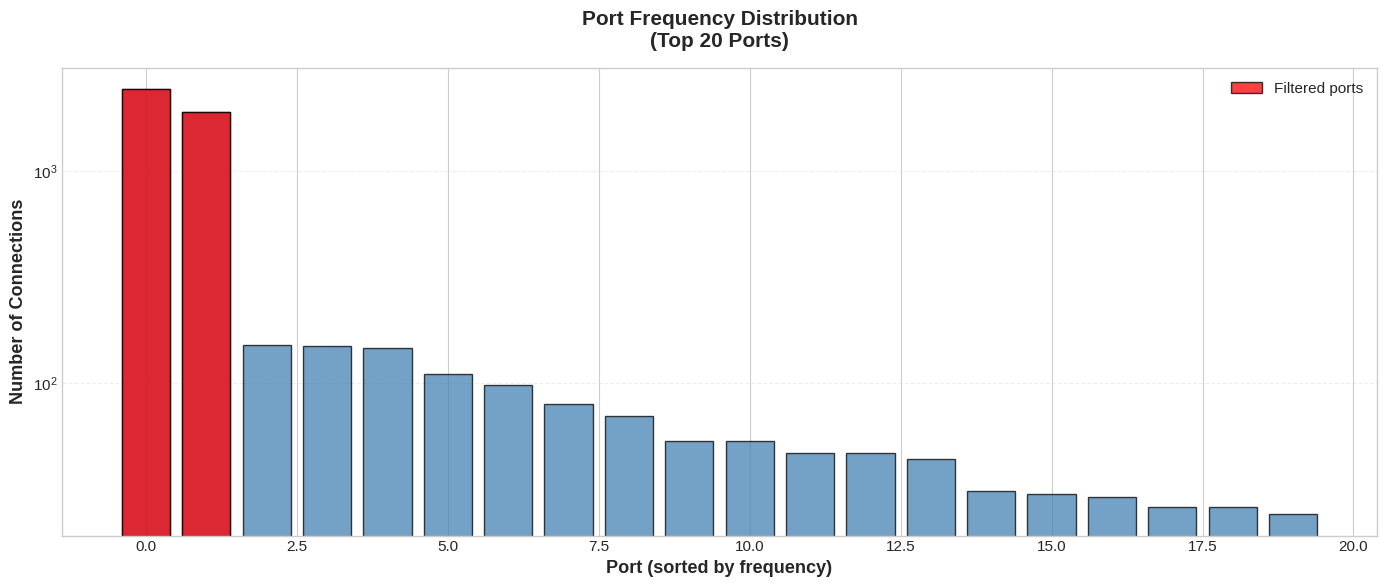


Filtering dominant ports: ['1p6', '1p17']
These ports account for 41.3% of connections


In [14]:
# Analyze port frequency
port_freq = Counter()
for port, pairs in stats_g21.items():
    port_freq[port] += len(pairs)

sorted_ports = sorted(port_freq.items(), key=lambda x: x[1], reverse=True)

print("=== Top 10 Ports by Frequency ===")
total_connections = sum(f for _, f in sorted_ports)
for i, (p, f) in enumerate(sorted_ports[:10], 1):
    print(f"{i:2d}. {p:10s}: {f:5d} connections ({100*f/total_connections:5.1f}%)")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.bar(range(min(20, len(sorted_ports))), [f for _, f in sorted_ports[:20]],
       color='steelblue', edgecolor='black', alpha=0.75)
ax.set_xlabel('Port (sorted by frequency)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Connections', fontsize=13, fontweight='bold')
ax.set_title('Port Frequency Distribution\n(Top 20 Ports)', fontsize=15, fontweight='bold', pad=15)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Highlight top 2
ax.bar([0, 1], [sorted_ports[0][1], sorted_ports[1][1]],
       color='red', edgecolor='black', alpha=0.75, label='Filtered ports')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Filter
top2_ports = [sorted_ports[0][0], sorted_ports[1][0]]
print(f"\nFiltering dominant ports: {top2_ports}")
print(f"These ports account for {100*sum(p[1] for p in sorted_ports[:2])/total_connections:.1f}% of connections")

In [15]:
def build_graph_filtered(stats, remove_ports):
    Gf = nx.Graph()
    for port, pairs in stats.items():
        if port in remove_ports:
            continue
        for u, v in pairs:
            Gf.add_edge(u, v)
    return Gf

G_filtered = build_graph_filtered(stats_g21, top2_ports)

print("\n=== Filtering Results ===")
print(f"Original: {G_cisco.number_of_edges()} edges, density {nx.density(G_cisco):.4f}")
print(f"Filtered: {G_filtered.number_of_edges()} edges, density {nx.density(G_filtered):.4f}")
print(f"Removed: {G_cisco.number_of_edges() - G_filtered.number_of_edges()} edges")
print(f"\nDensity reduced from {nx.density(G_cisco)*100:.1f}% to {nx.density(G_filtered)*100:.1f}%")


=== Filtering Results ===
Original: 1275 edges, density 0.9615
Filtered: 682 edges, density 0.5143
Removed: 593 edges

Density reduced from 96.2% to 51.4%


### 6.5 Degree Profiles Before and After Filtering

**Goal:** Show how removing dominant ports reshapes the g21 topology.
- Raw graph is almost fully connected; filtered graph reduces the hub effect.
- Both linear and log-log views highlight degree compression after filtering.


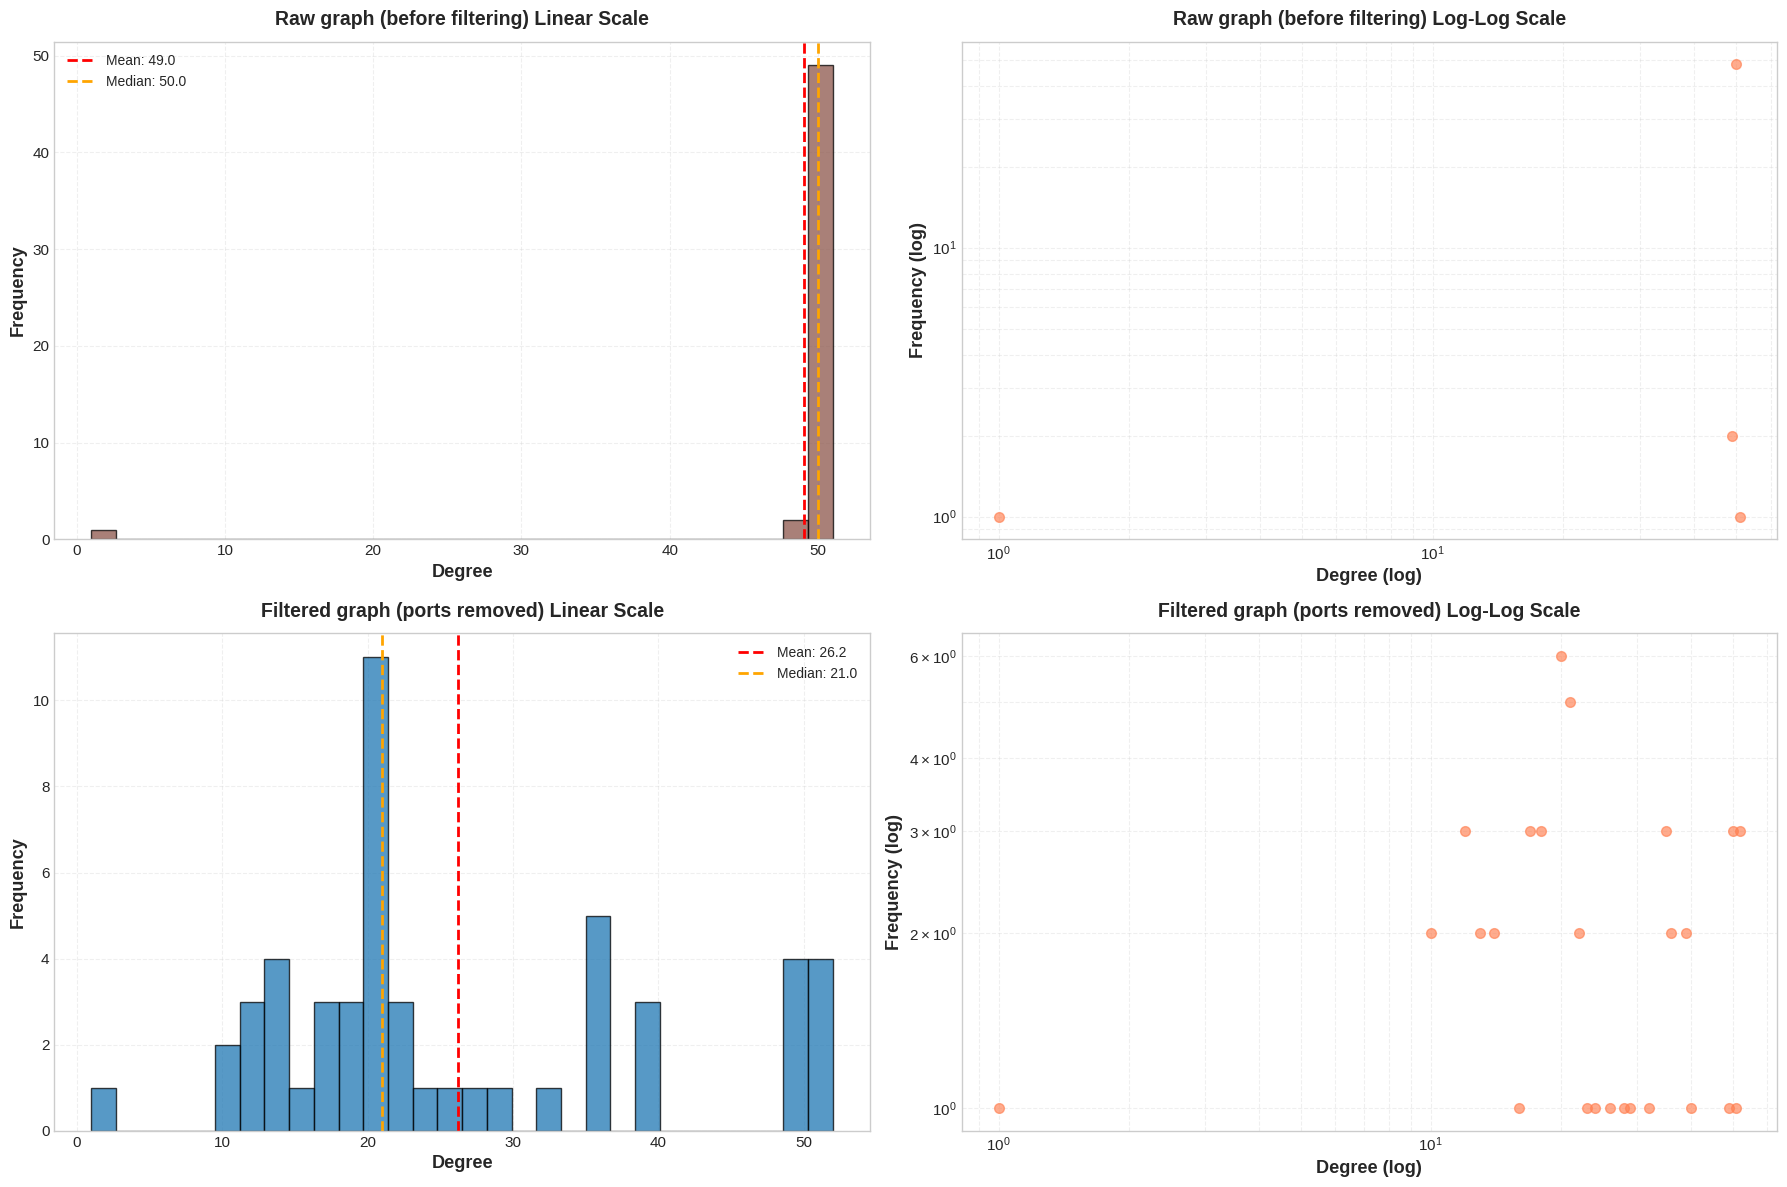

=== Degree Statistics ===
Raw graph:     range [1, 51], mean 49.04, median 50.0
Filtered graph: range [1, 52], mean 26.23, median 21.0
Filtering collapses the extreme high-degree connections, revealing a narrower degree spread.


In [16]:
degrees_raw = [G_cisco.degree(n) for n in G_cisco.nodes()]
degrees_filtered = [G_filtered.degree(n) for n in G_filtered.nodes()]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plots = [
    (0, degrees_raw, 'Raw graph (before filtering)', '#8c564b'),
    (1, degrees_filtered, 'Filtered graph (ports removed)', '#1f77b4')
]

for row, degrees, title, color in plots:
    mean_val = np.mean(degrees)
    median_val = np.median(degrees)

    # Linear histogram
    ax_hist = axes[row, 0]
    ax_hist.hist(degrees, bins=30, edgecolor='black', alpha=0.75, color=color)
    ax_hist.set_xlabel('Degree', fontsize=13)
    ax_hist.set_ylabel('Frequency', fontsize=13)
    ax_hist.set_title(f'{title} Linear Scale', fontsize=14, pad=12)
    ax_hist.grid(True, alpha=0.3, linestyle='--')
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax_hist.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax_hist.legend(fontsize=10)

    # Log-log distribution
    ax_log = axes[row, 1]
    degree_counts = Counter(degrees)
    degree_sorted = sorted(degree_counts.items())
    x_vals = [d for d, _ in degree_sorted if d > 0]
    y_vals = [c for d, c in degree_sorted if d > 0]

    ax_log.loglog(x_vals, y_vals, 'o', alpha=0.65, color='coral', markersize=7)
    ax_log.set_xlabel('Degree (log)', fontsize=13)
    ax_log.set_ylabel('Frequency (log)', fontsize=13)
    ax_log.set_title(f'{title} Log-Log Scale', fontsize=14, pad=12)
    ax_log.grid(True, alpha=0.3, which='both', linestyle='--')

plt.tight_layout()
plt.show()

print("=== Degree Statistics ===")
print(f"Raw graph:     range [{min(degrees_raw)}, {max(degrees_raw)}], mean {np.mean(degrees_raw):.2f}, median {np.median(degrees_raw):.1f}")
print(f"Filtered graph: range [{min(degrees_filtered)}, {max(degrees_filtered)}], mean {np.mean(degrees_filtered):.2f}, median {np.median(degrees_filtered):.1f}")
print("Filtering collapses the extreme high-degree connections, revealing a narrower degree spread.")


### 6.6 Weighted Graph Construction

Edge weights based on port diversity using IDF (Inverse Document Frequency) approach.

In [17]:
def build_weighted_from_filtered(G_filtered, stats):
    edge_port_counts = defaultdict(set)
    for port, pairs in stats.items():
        for u, v in pairs:
            if u == v:
                continue
            if u > v:
                u, v = v, u
            if G_filtered.has_edge(u, v):
                edge_port_counts[(u, v)].add(port)

    port_freq = defaultdict(int)
    for (u, v), ports in edge_port_counts.items():
        for p in ports:
            port_freq[p] += 1

    total_pairs = sum(port_freq.values())

    port_idf = {}
    for p, f in port_freq.items():
        port_idf[p] = math.log((total_pairs + 1) / (f + 1))

    Gw = nx.Graph()
    Gw.add_nodes_from(G_filtered.nodes())
    for (u, v), ports in edge_port_counts.items():
        w = sum(port_idf[p] for p in ports)
        Gw.add_edge(u, v, weight=w)

    return Gw

G_weighted = build_weighted_from_filtered(G_filtered, stats_g21)
print(f"✓ Weighted graph: {G_weighted.number_of_edges()} edges with port-diversity weights")

✓ Weighted graph: 675 edges with port-diversity weights


## 7. Cisco: Community Detection (Undirected)

### 7.1 Algorithm Execution

In [18]:
print("Running undirected algorithms on weighted graph...\n")

# Louvain
partition_louvain_c = community_louvain.best_partition(G_weighted, weight="weight")
communities_louvain_c = {}
for node, comm_id in partition_louvain_c.items():
    if comm_id not in communities_louvain_c:
        communities_louvain_c[comm_id] = []
    communities_louvain_c[comm_id].append(node)

print(f"✓ Louvain: {len(communities_louvain_c)} communities")

# Label Propagation
communities_lp_c = list(nx_community.label_propagation_communities(G_weighted))
partition_lp_c = {}
for idx, comm in enumerate(communities_lp_c):
    for node in comm:
        partition_lp_c[node] = idx

print(f"✓ Label Propagation: {len(communities_lp_c)} communities")

# Greedy Modularity
communities_greedy_c = list(nx_community.greedy_modularity_communities(G_weighted, weight="weight"))
partition_greedy_c = {}
for idx, comm in enumerate(communities_greedy_c):
    for node in comm:
        partition_greedy_c[node] = idx

print(f"✓ Greedy Modularity: {len(communities_greedy_c)} communities")

if len(communities_lp_c) == 1:
    print("\n** Note: Label Propagation found only 1 community due to remaining high density (51%) **")

Running undirected algorithms on weighted graph...

✓ Louvain: 2 communities
✓ Label Propagation: 1 communities
✓ Greedy Modularity: 2 communities

** Note: Label Propagation found only 1 community due to remaining high density (51%) **


### 7.2 Visualizing Cisco Communities (Undirected)

Community layouts mirror the LastFM visuals, using the filtered undirected graph with Louvain, Label Propagation, and Greedy Modularity partitions.


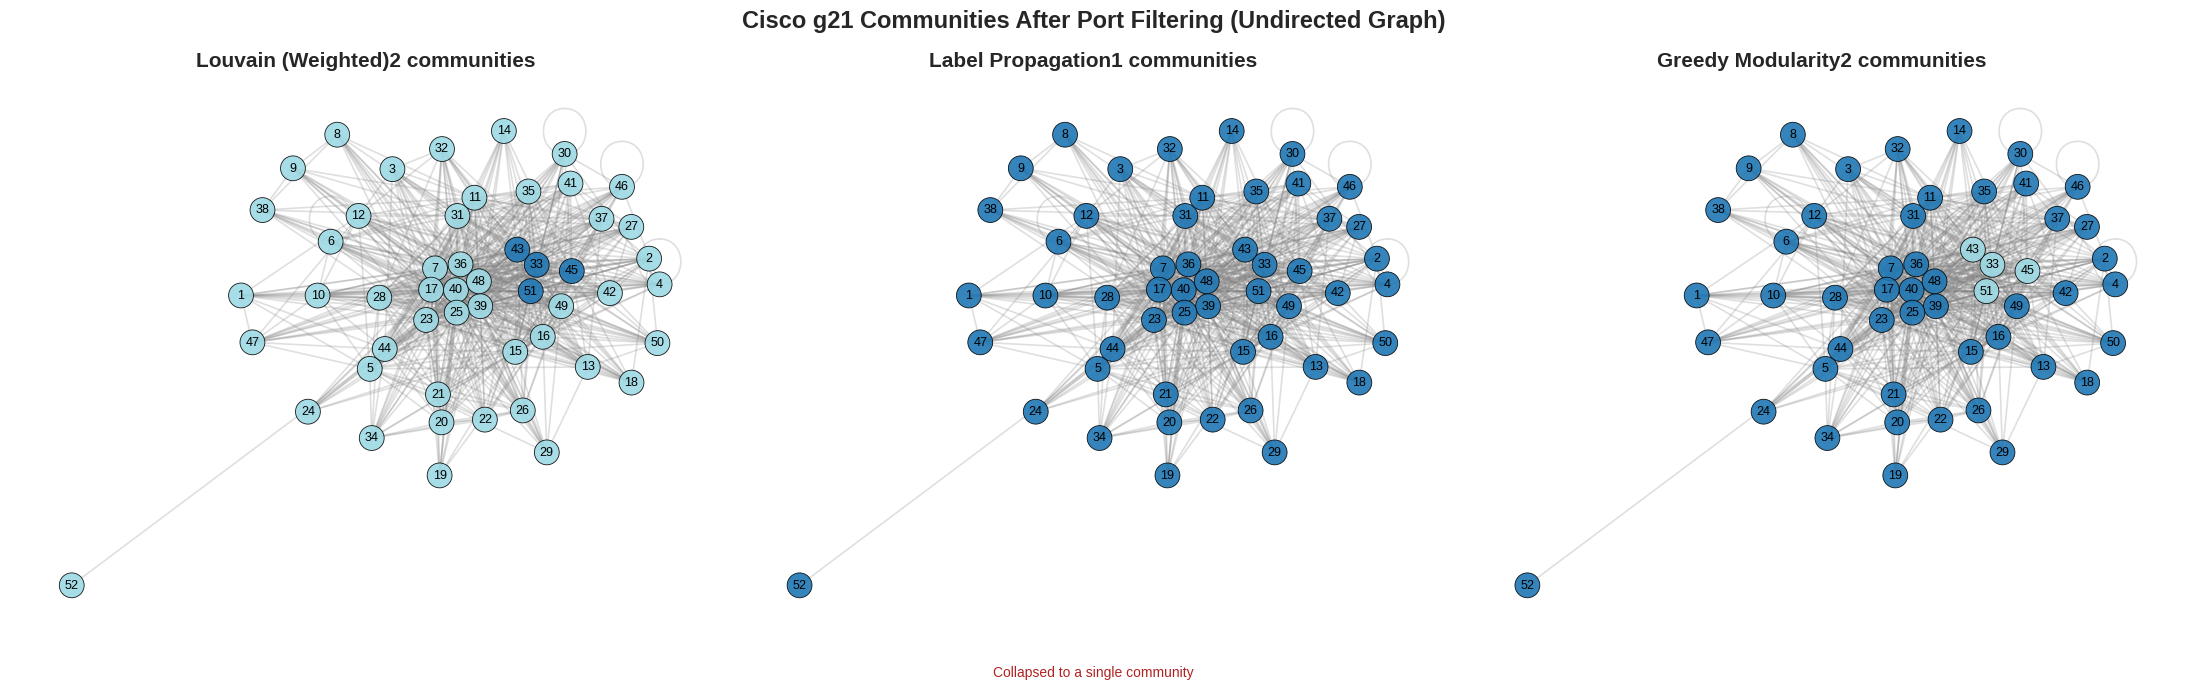

Filtered undirected graph (52 nodes, ~51% density) with community assignments visualized.


In [20]:
pos_cisco = nx.spring_layout(G_filtered, k=0.55, iterations=200, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

algo_partitions = [
    ('Louvain (Weighted)', partition_louvain_c),
    ('Label Propagation', partition_lp_c),
    ('Greedy Modularity', partition_greedy_c)
]

for ax, (title, partition) in zip(axes, algo_partitions):
    node_colors = [partition.get(node, 0) for node in G_filtered.nodes()]

    nx.draw_networkx_edges(G_filtered, pos_cisco, alpha=0.25, width=1.2, ax=ax, edge_color='gray')
    nx.draw_networkx_nodes(G_filtered, pos_cisco, node_color=node_colors, node_size=320,
                           cmap='tab20', alpha=0.9, ax=ax, edgecolors='black', linewidths=0.6)
    nx.draw_networkx_labels(G_filtered, pos_cisco, font_size=9, ax=ax)

    ax.set_title(f"{title}{len(set(node_colors))} communities", fontsize=15, fontweight='bold', pad=12)
    ax.axis('off')

    if len(set(node_colors)) == 1:
        ax.text(0.5, -0.08, 'Collapsed to a single community', transform=ax.transAxes,
                ha='center', fontsize=10, color='firebrick')

plt.suptitle('Cisco g21 Communities After Port Filtering (Undirected Graph)',
             fontsize=17, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Filtered undirected graph (52 nodes, ~51% density) with community assignments visualized.")


## 8. Cisco: Community Detection (Directed)

### 8.1 Directed Graph Construction

In [21]:
def build_directed_graph_filtered(stats, remove_ports):
    Gf = nx.DiGraph()
    for port, pairs in stats.items():
        if port in remove_ports:
            continue
        for u, v in pairs:
            Gf.add_edge(u, v)
    return Gf

G_directed = build_directed_graph_filtered(stats_g21, top2_ports)

print("=== Directed Graph Statistics ===")
print(f"Nodes: {G_directed.number_of_nodes()}")
print(f"Directed edges: {G_directed.number_of_edges()}")
print(f"Density: {nx.density(G_directed):.4f}")
print(f"Strongly connected: {nx.is_strongly_connected(G_directed)}")
print(f"Weakly connected: {nx.is_weakly_connected(G_directed)}")

=== Directed Graph Statistics ===
Nodes: 52
Directed edges: 952
Density: 0.3590
Strongly connected: False
Weakly connected: True


### 8.2 Directed Algorithms

**Girvan-Newman:** Divisive hierarchical method
**Infomap:** Information-flow based method

In [22]:
print("Running directed algorithms...\n")

# Girvan-Newman
communities_gn_iter = girvan_newman(G_directed)
target_num = 8
for i, communities in enumerate(communities_gn_iter):
    if i == target_num - 1:
        communities_gn = list(communities)
        break

partition_gn = {}
for idx, comm in enumerate(communities_gn):
    for node in comm:
        partition_gn[node] = idx

print(f"✓ Girvan-Newman: {len(communities_gn)} communities")

# Infomap
im = Infomap(directed=True, silent=True)
node_to_id = {node: idx for idx, node in enumerate(G_directed.nodes())}
id_to_node = {idx: node for node, idx in node_to_id.items()}

for u, v in G_directed.edges():
    im.add_link(node_to_id[u], node_to_id[v])

im.run()

communities_infomap = {}
partition_infomap = {}

for node_id in im.tree:
    if node_id.is_leaf:
        module_id = node_id.module_id
        orig_node = id_to_node.get(node_id.node_id)
        if orig_node:
            if module_id not in communities_infomap:
                communities_infomap[module_id] = []
            communities_infomap[module_id].append(orig_node)
            partition_infomap[orig_node] = module_id

print(f"✓ Infomap: {len(communities_infomap)} communities")

Running directed algorithms...

✓ Girvan-Newman: 9 communities
✓ Infomap: 1 communities


## 9. Cisco: Evaluation Against Ground Truth

### 9.1 External Validation Metrics

In [23]:
def jaccard(a, b):
    a, b = set(a), set(b)
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union > 0 else 0.0

def average_best_jaccard(found_communities, gt_groups, min_size=1, only_if_intersects_gt=True):
    gt_groups = [set(g) for g in gt_groups]
    scores = []
    for comm in found_communities:
        comm = set(comm)
        if len(comm) < min_size:
            continue
        if only_if_intersects_gt:
            if not any(len(comm & g) > 0 for g in gt_groups):
                continue
        best = max(jaccard(comm, g) for g in gt_groups)
        scores.append(best)
    return sum(scores) / len(scores) if scores else 0.0

# Prepare communities
found_louvain = [set(nodes) for nodes in communities_louvain_c.values()]
found_lp = [set(nodes) for nodes in communities_lp_c]
found_greedy = [set(nodes) for nodes in communities_greedy_c]
found_gn = [set(comm) for comm in communities_gn]
found_infomap = [set(comm) for comm in communities_infomap.values()]

# Compute Jaccard
jaccard_louvain = average_best_jaccard(found_louvain, gt_groups)
jaccard_lp = average_best_jaccard(found_lp, gt_groups)
jaccard_greedy = average_best_jaccard(found_greedy, gt_groups)
jaccard_gn = average_best_jaccard(found_gn, gt_groups)
jaccard_infomap = average_best_jaccard(found_infomap, gt_groups)

print("=== Jaccard Overlap (vs Ground Truth) ===\n")
print(f"Louvain (Undirected):          {jaccard_louvain:.4f}")
print(f"Label Propagation (Undirected): {jaccard_lp:.4f}")
print(f"Greedy Modularity (Undirected): {jaccard_greedy:.4f}")
print(f"Girvan-Newman (Directed):       {jaccard_gn:.4f}")
print(f"Infomap (Directed):             {jaccard_infomap:.4f}")

=== Jaccard Overlap (vs Ground Truth) ===

Louvain (Undirected):          0.5312
Label Propagation (Undirected): 0.0769
Greedy Modularity (Undirected): 0.5312
Girvan-Newman (Directed):       0.3223
Infomap (Directed):             0.0769


In [24]:
# Prepare labels for sklearn metrics
node_to_gt = {}
for gt_id, group in enumerate(gt_groups):
    for node in group:
        node_to_gt[node] = gt_id

# Undirected labels
gt_labels = []
pred_louvain = []
pred_lp = []
pred_greedy = []

for node in sorted(G_weighted.nodes()):
    if node in node_to_gt:
        gt_labels.append(node_to_gt[node])
        pred_louvain.append(partition_louvain_c.get(node, -1))
        pred_lp.append(partition_lp_c.get(node, -1))
        pred_greedy.append(partition_greedy_c.get(node, -1))

# Directed labels
gt_labels_dir = []
pred_gn = []
pred_infomap = []

for node in sorted(G_directed.nodes()):
    if node in node_to_gt:
        gt_labels_dir.append(node_to_gt[node])
        pred_gn.append(partition_gn.get(node, -1))
        pred_infomap.append(partition_infomap.get(node, -1))

# Compute metrics
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

results = []
for name, gt, pred in [
    ("Louvain (Undirected)", gt_labels, pred_louvain),
    ("Label Prop (Undirected)", gt_labels, pred_lp),
    ("Greedy Mod (Undirected)", gt_labels, pred_greedy),
    ("Girvan-Newman (Directed)", gt_labels_dir, pred_gn),
    ("Infomap (Directed)", gt_labels_dir, pred_infomap)
]:
    results.append({
        'Algorithm': name,
        'NMI': normalized_mutual_info_score(gt, pred),
        'ARI': adjusted_rand_score(gt, pred),
        'AMI': adjusted_mutual_info_score(gt, pred)
    })

print("\n=== Clustering Quality Metrics (vs Ground Truth) ===\n")
print("Algorithm                      |   NMI   |   ARI   |   AMI")
print("-" * 65)
for r in results:
    print(f"{r['Algorithm']:30s} | {r['NMI']:7.4f} | {r['ARI']:7.4f} | {r['AMI']:7.4f}")

print("\nNote: Higher values indicate better alignment with ground truth (range: 0-1)")


=== Clustering Quality Metrics (vs Ground Truth) ===

Algorithm                      |   NMI   |   ARI   |   AMI
-----------------------------------------------------------------
Louvain (Undirected)           |  0.1646 |  0.0113 |  0.0797
Label Prop (Undirected)        |  0.0000 |  0.0000 |  0.0000
Greedy Mod (Undirected)        |  0.1646 |  0.0113 |  0.0797
Girvan-Newman (Directed)       |  0.2963 |  0.0072 |  0.0375
Infomap (Directed)             |  0.0000 |  0.0000 |  0.0000

Note: Higher values indicate better alignment with ground truth (range: 0-1)


### 9.2 Comprehensive Comparison

In [25]:
comparison_df_cisco = pd.DataFrame({
    'Algorithm': [
        'Louvain (Undirected)',
        'Label Prop (Undirected)',
        'Greedy Mod (Undirected)',
        'Girvan-Newman (Directed)',
        'Infomap (Directed)'
    ],
    'Jaccard': [jaccard_louvain, jaccard_lp, jaccard_greedy, jaccard_gn, jaccard_infomap],
    'NMI': [results[0]['NMI'], results[1]['NMI'], results[2]['NMI'], results[3]['NMI'], results[4]['NMI']],
    'ARI': [results[0]['ARI'], results[1]['ARI'], results[2]['ARI'], results[3]['ARI'], results[4]['ARI']],
    'AMI': [results[0]['AMI'], results[1]['AMI'], results[2]['AMI'], results[3]['AMI'], results[4]['AMI']]
})

print("\n" + "="*80)
print("CISCO COMPREHENSIVE COMPARISON")
print("="*80)
print(comparison_df_cisco.to_string(index=False))

print("\n=== Best Performers ===")
for metric in ['Jaccard', 'NMI', 'ARI', 'AMI']:
    best_idx = comparison_df_cisco[metric].idxmax()
    best_algo = comparison_df_cisco.loc[best_idx, 'Algorithm']
    best_val = comparison_df_cisco.loc[best_idx, metric]
    print(f"{metric:10s}: {best_algo:30s} ({best_val:.4f})")


CISCO COMPREHENSIVE COMPARISON
               Algorithm  Jaccard      NMI      ARI      AMI
    Louvain (Undirected) 0.531250 0.164588 0.011285 0.079694
 Label Prop (Undirected) 0.076923 0.000000 0.000000 0.000000
 Greedy Mod (Undirected) 0.531250 0.164588 0.011285 0.079694
Girvan-Newman (Directed) 0.322270 0.296333 0.007164 0.037537
      Infomap (Directed) 0.076923 0.000000 0.000000 0.000000

=== Best Performers ===
Jaccard   : Louvain (Undirected)           (0.5312)
NMI       : Girvan-Newman (Directed)       (0.2963)
ARI       : Louvain (Undirected)           (0.0113)
AMI       : Greedy Mod (Undirected)        (0.0797)


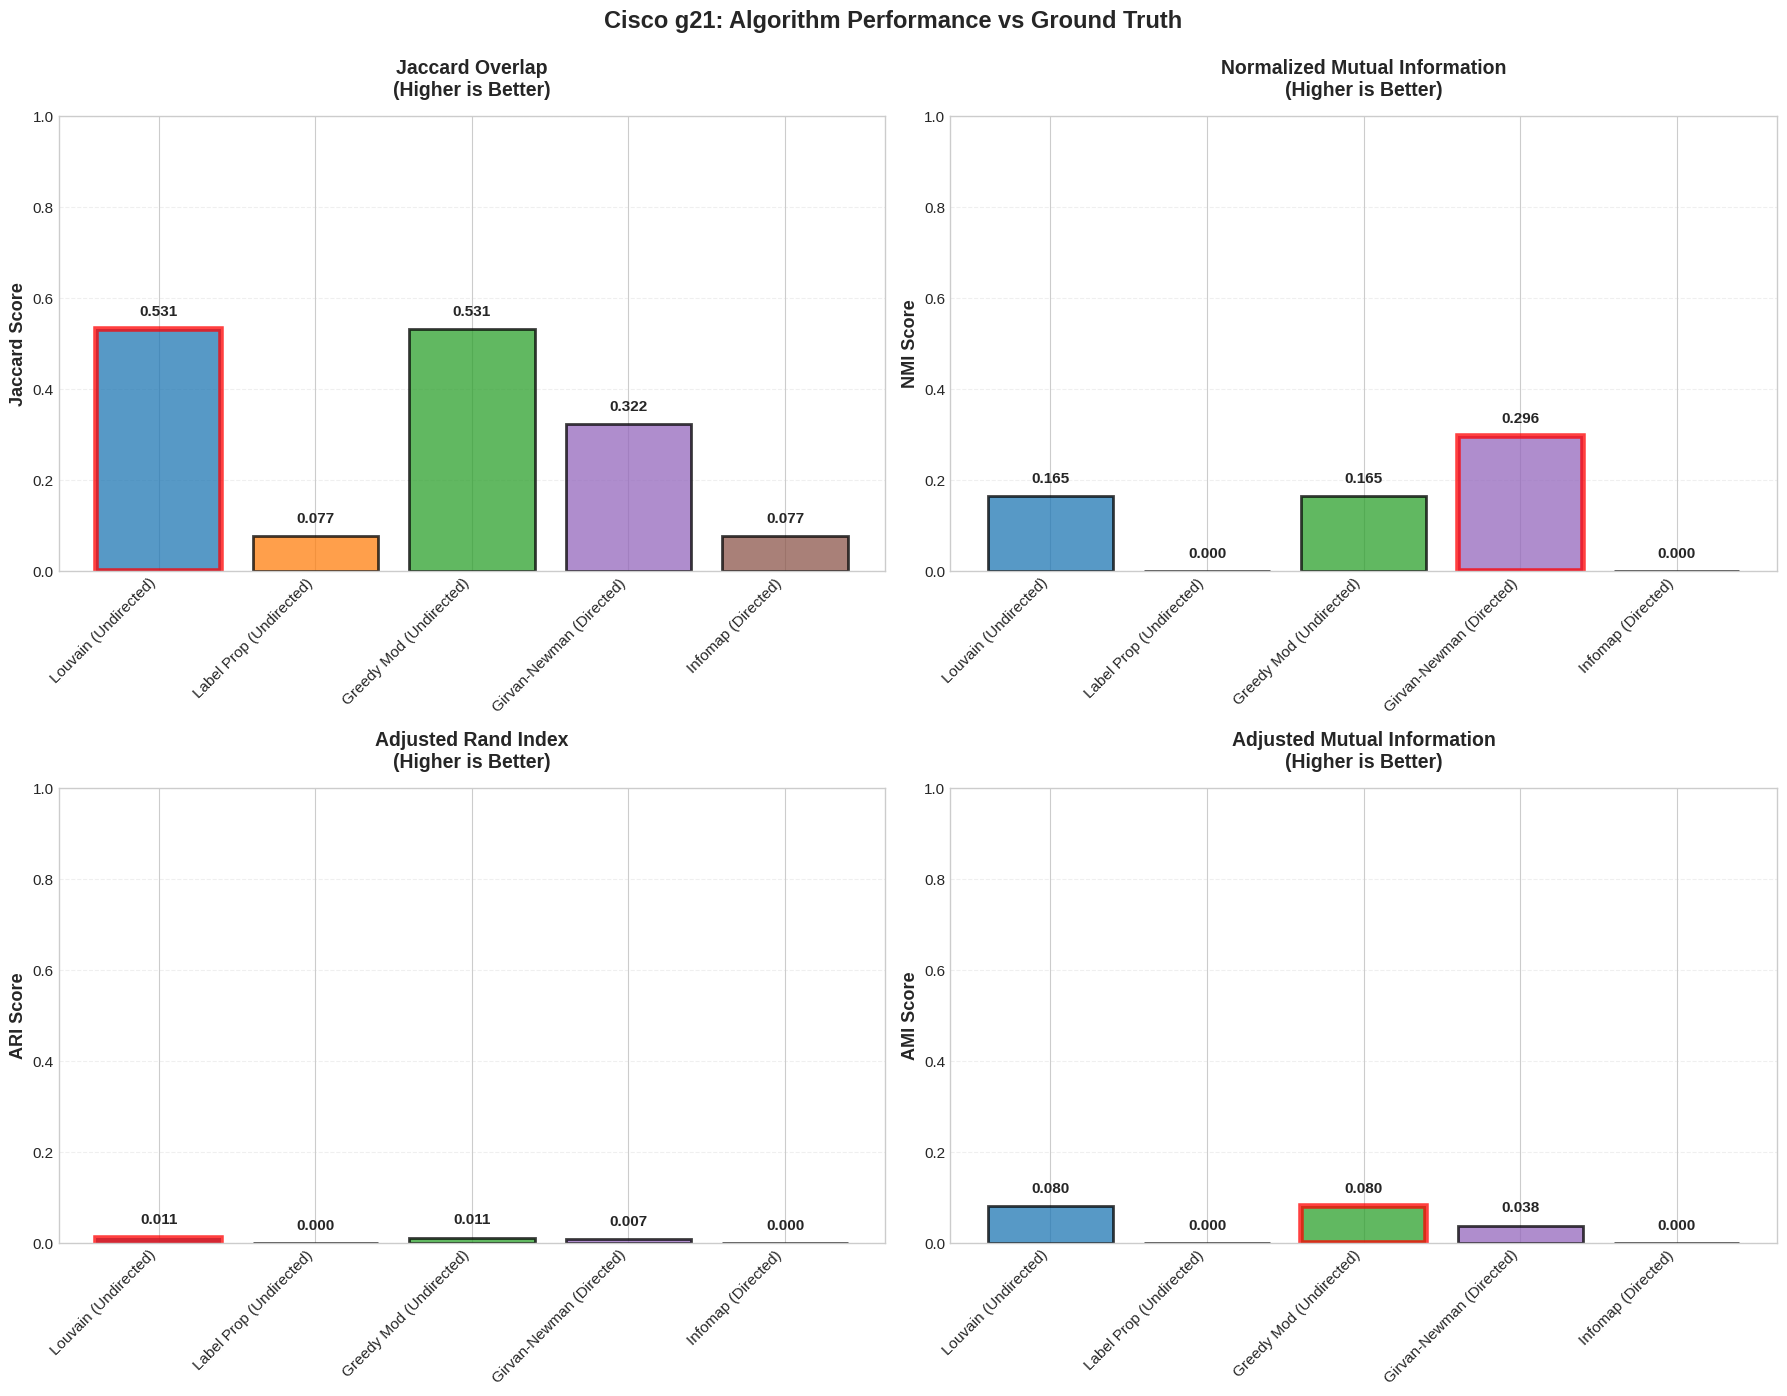


** Red borders indicate best-performing algorithm for each metric **


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

metrics = ['Jaccard', 'NMI', 'ARI', 'AMI']
titles = ['Jaccard Overlap', 'Normalized Mutual Information',
          'Adjusted Rand Index', 'Adjusted Mutual Information']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]

    bars = ax.bar(range(len(comparison_df_cisco)), comparison_df_cisco[metric],
                   color=colors, alpha=0.75, edgecolor='black', linewidth=2)

    ax.set_xticks(range(len(comparison_df_cisco)))
    ax.set_xticklabels(comparison_df_cisco['Algorithm'], rotation=45, ha='right', fontsize=11)
    ax.set_ylabel(f'{metric} Score', fontsize=13, fontweight='bold')
    ax.set_title(f'{title}\n(Higher is Better)', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Value labels
    for i, v in enumerate(comparison_df_cisco[metric]):
        ax.text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

    # Highlight best
    best_idx = comparison_df_cisco[metric].idxmax()
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(4)

plt.suptitle('Cisco g21: Algorithm Performance vs Ground Truth',
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n** Red borders indicate best-performing algorithm for each metric **")

### 9.3 Cisco Key Findings

**Ground Truth Validation Results:**

1. **Best Algorithms** (by metric):
   - **Jaccard:** Louvain & Greedy Modularity tied (0.53)
   - **NMI:** Girvan-Newman (0.30)
   - **ARI:** Louvain & Greedy Modularity (0.01)
   - **AMI:** Louvain & Greedy Modularity (0.08)

2. **Performance Analysis:**
   - Moderate alignment with ground truth (Jaccard ~0.53)
   - NMI shows Girvan-Newman captures flow structure better than others
   - Label Propagation collapses to one community (all metrics ~0)
   - Directed vs. undirected differences are modest aside from NMI

3. **Challenges:**
   - Extremely high density obscures community boundaries
   - Port filtering helps but density remains 51%
   - Small graph size (52 nodes) limits statistical power
   - Functional groupings only partially align with topology

**Methodological Insight:**
Ground truth highlights where topology diverges from intended organization. Even after filtering, high density and overlapping roles cap achievable scores.

---

## 10. Comparative Discussion

### 10.1 Cross-Dataset Algorithm Performance

| Algorithm | LastFM Modularity | Cisco Jaccard | Cisco NMI | Cisco ARI | Cisco AMI |
|-----------|-------------------|---------------|-----------|-----------|-----------|
| **Louvain** | 0.814 | 0.531 | 0.165 | 0.011 | 0.080 |
| **Label Prop** | 0.752 | 0.077 | 0.000 | 0.000 | 0.000 |
| **Greedy Mod** | 0.796 | 0.531 | 0.165 | 0.011 | 0.080 |
| **Girvan-Newman** | — | 0.322 | 0.296 | 0.007 | 0.038 |
| **Infomap** | — | 0.077 | 0.000 | 0.000 | 0.000 |

### 10.2 Key Insights

**1. Density is Critical**
- LastFM (0.096% density): all undirected algorithms deliver strong communities
- Cisco (96% → 51% density): only Louvain/Greedy hold up; Label Propagation collapses

**2. Directed vs Undirected**
- Directed Girvan-Newman boosts NMI but not Jaccard/ARI/AMI
- Direction helps when flows matter, but benefits are modest here

**3. Evaluation Methodology Matters**
- **Without GT (LastFM):** rely on modularity/conductance
- **With GT (Cisco):** external metrics expose gaps between structure and function

**4. Scale Effects**
- Large sparse (LastFM): algorithms scale and separate well
- Small dense (Cisco): filtering is mandatory, results remain coarse

### 10.3 Practical Recommendations

**For Social Networks (sparse, undirected, no GT):**
- Prefer Louvain for balance; Greedy Modularity if intra-edge retention matters
- Validate with modularity and conductance

**For Traffic Networks (dense, directed, with GT):**
- Filter dominant ports before community detection
- Use Louvain/Greedy as baselines; try Girvan-Newman when direction is informative
- Expect imperfect alignment with functional groups

**General:**
- Check density first (>50% requires filtering or specialized methods)
- Combine intrinsic and external metrics when ground truth exists
- Compare multiple algorithms to gauge stability

---

## 11. Conclusions

### 11.1 Summary of Findings

**LastFM Asia (Social Network)**
- 7,624 nodes, 0.096% density, undirected, no ground truth
- **Louvain**: highest modularity (0.814) and lowest conductance (0.136)
- Greedy Modularity close behind; Label Propagation least cohesive
- Intrinsic metrics provide the main quality signals

**Cisco g21 (Network Traffic)**
- 52 nodes, density reduced from 96% to 51% after port filtering
- **Best Jaccard/ARI/AMI:** Louvain & Greedy Modularity (0.53 / 0.01 / 0.08)
- **Best NMI:** Girvan-Newman (0.30) leveraging directionality
- Label Propagation collapses to one community under high density

### 11.2 Theoretical Contributions

1. **Method depends on data regime:** sparse/no-GT relies on intrinsic metrics; dense/with-GT demands filtering and external validation.
2. **Density drives outcomes:** once density passes ~50%, propagation methods fail and modularity methods degrade.
3. **Topology vs function diverge:** moderate ground-truth scores show functional groups are only partially encoded in connectivity.

### 11.3 Limitations

- Only two datasets; broader coverage needed for generality
- Cisco ground truth reflects intended roles, not emergent structure
- Girvan-Newman is infeasible for much larger graphs

### 11.4 Future Directions

- Multi-scale experiments across sizes and densities
- Temporal analysis for evolving communities
- Hybrid/ensemble community detection with explainability focus

### 11.5 Final Remarks

Match algorithms to network density, direction, and label availability. Use multiple metrics, filter dense graphs, and expect imperfect alignment between connectivity and functional organization.

---

## 12. Reference (Datasets)

**Rozemberczki, B., & Sarkar, R. (2020).**  
*Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models.*  
In **Proceedings of the 29th ACM International Conference on Information and Knowledge Management (CIKM ’20)**, pp. 1325–1334. ACM.

https://snap.stanford.edu/data/feather-lastfm-social.html   

**Madani, O., Averineni, S. A., & Gandham, S. (2022).**  
*A Dataset of Networks of Computing Hosts.*  
In **Proceedings of the 2022 ACM on International Workshop on Security and Privacy Analytics**, pp. 100–104.

https://snap.stanford.edu/data/cisco-networks.html